Model karşılaştırma grafiği başarıyla kaydedildi!


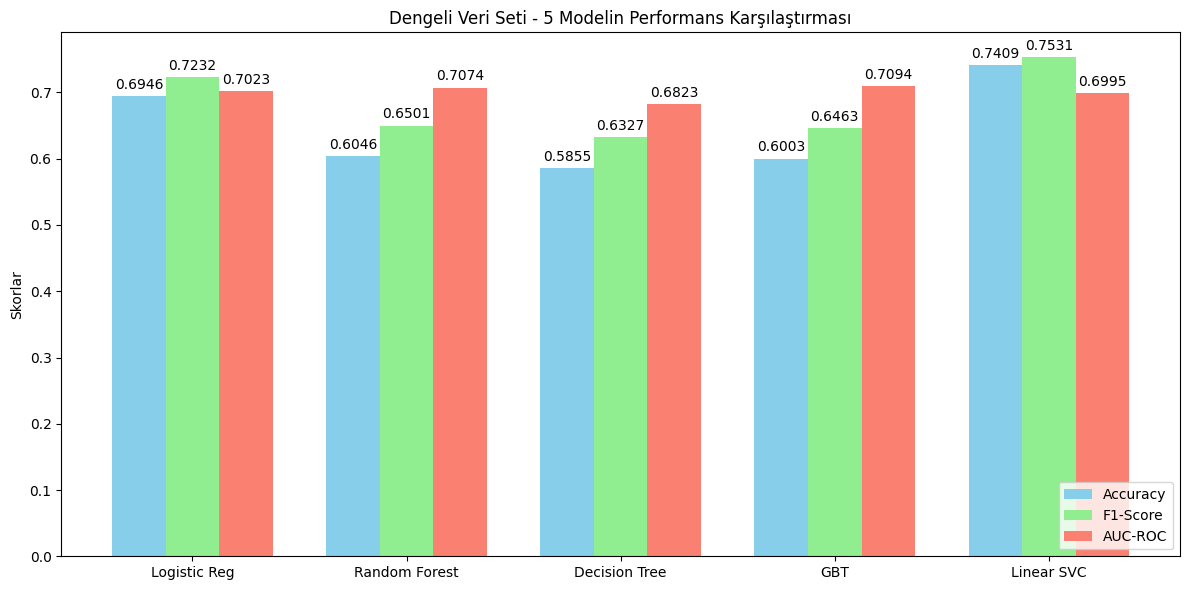

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Yeni dengeli eğitim sonuçları
modeller = ['Logistic Reg', 'Random Forest', 'Decision Tree', 'GBT', 'Linear SVC']
accuracy = [0.6946, 0.6046, 0.5855, 0.6003, 0.7409]
f1_score = [0.7232, 0.6501, 0.6327, 0.6463, 0.7531]
auc_roc =  [0.7023, 0.7074, 0.6823, 0.7094, 0.6995]

x = np.arange(len(modeller))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x, f1_score, width, label='F1-Score', color='lightgreen')
rects3 = ax.bar(x + width, auc_roc, width, label='AUC-ROC', color='salmon')

ax.set_ylabel('Skorlar')
ax.set_title('Dengeli Veri Seti - 5 Modelin Performans Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(modeller)
ax.legend(loc='lower right')

ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')
ax.bar_label(rects3, padding=3, fmt='%.4f')

fig.tight_layout()
plt.savefig("/Volumes/workspace/default/steam/adim7_dengeli_model_karsilastirma.png", bbox_inches='tight', dpi=300)
print("Model karşılaştırma grafiği başarıyla kaydedildi!")
plt.show()

Veriler okunuyor ve dengeleniyor... Lütfen bekleyin.
En iyi model (Logistic Regression) görselleştirme için hazırlanıyor...


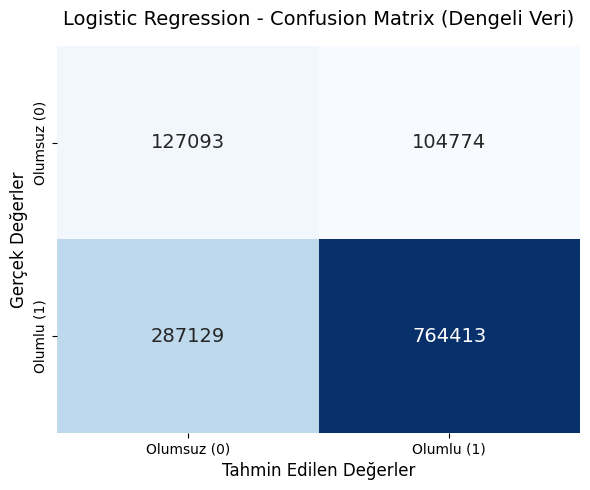

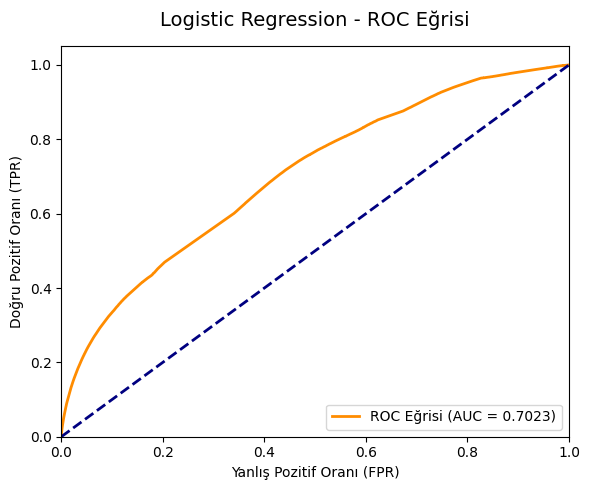

Confusion Matrix ve ROC Eğrisi başarıyla kaydedildi!


In [0]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import when, col

# ==========================================
# 1. EKSİK OLAN KISIM: Veri Hazırlığı ve Dengeleme (Undersampling)
# ==========================================
print("Veriler okunuyor ve dengeleniyor... Lütfen bekleyin.")
features_path = "/Volumes/workspace/default/steam/steam_reviews_features"
df_features = spark.read.format("delta").load(features_path)

df_ml = df_features.withColumn("label", when(col("voted_up").cast("string").isin("1", "true"), 1.0).otherwise(0.0))

feature_columns = ["review_length", "word_count", "is_voted", "has_positive_word", "has_negative_word"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
final_data = assembler.transform(df_ml).select("features", "label")

# Veriyi Train/Test olarak böl
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

# Sadece eğitim verisini dengele (Undersampling)
negatif_df = train_data.filter(col("label") == 0.0)
olumlu_df = train_data.filter(col("label") == 1.0)
oran = negatif_df.count() / olumlu_df.count()
olumlu_alt_kume = olumlu_df.sample(withReplacement=False, fraction=oran, seed=42)
balanced_train_data = negatif_df.unionByName(olumlu_alt_kume)

# ==========================================
# 2. MODEL EĞİTİMİ (Dengeli Veriyle)
# ==========================================
print("En iyi model (Logistic Regression) görselleştirme için hazırlanıyor...")
lr_best = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)
lr_model = lr_best.fit(balanced_train_data)

# Test verisinde tahmin (Gerçek hayat simülasyonu)
predictions = lr_model.transform(test_data)
preds_df = predictions.select("label", "prediction", "probability").toPandas()

# ROC eğrisi için pozitif (1) sınıfına ait tahmin olasılıklarını çekelim
preds_df['prob_positive'] = preds_df['probability'].apply(lambda x: x[1])

# ==========================================
# 3. GÖRSEL 1: CONFUSION MATRIX (Karmaşıklık Matrisi)
# ==========================================
cm = confusion_matrix(preds_df['label'], preds_df['prediction'])

fig1, ax1 = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Olumsuz (0)', 'Olumlu (1)'],
            yticklabels=['Olumsuz (0)', 'Olumlu (1)'], annot_kws={"size": 14})
plt.ylabel('Gerçek Değerler', fontsize=12)
plt.xlabel('Tahmin Edilen Değerler', fontsize=12)
plt.title('Logistic Regression - Confusion Matrix (Dengeli Veri)', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/steam/adim7_lr_confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()

# ==========================================
# 4. GÖRSEL 2: ROC EĞRİSİ 
# ==========================================
fpr, tpr, thresholds = roc_curve(preds_df['label'], preds_df['prob_positive'])
roc_auc = auc(fpr, tpr)

fig2, ax2 = plt.subplots(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)')
plt.ylabel('Doğru Pozitif Oranı (TPR)')
plt.title('Logistic Regression - ROC Eğrisi', fontsize=14, pad=15)
plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/steam/adim7_lr_roc_curve.png", bbox_inches='tight', dpi=300)
plt.show()
print("Confusion Matrix ve ROC Eğrisi başarıyla kaydedildi!")

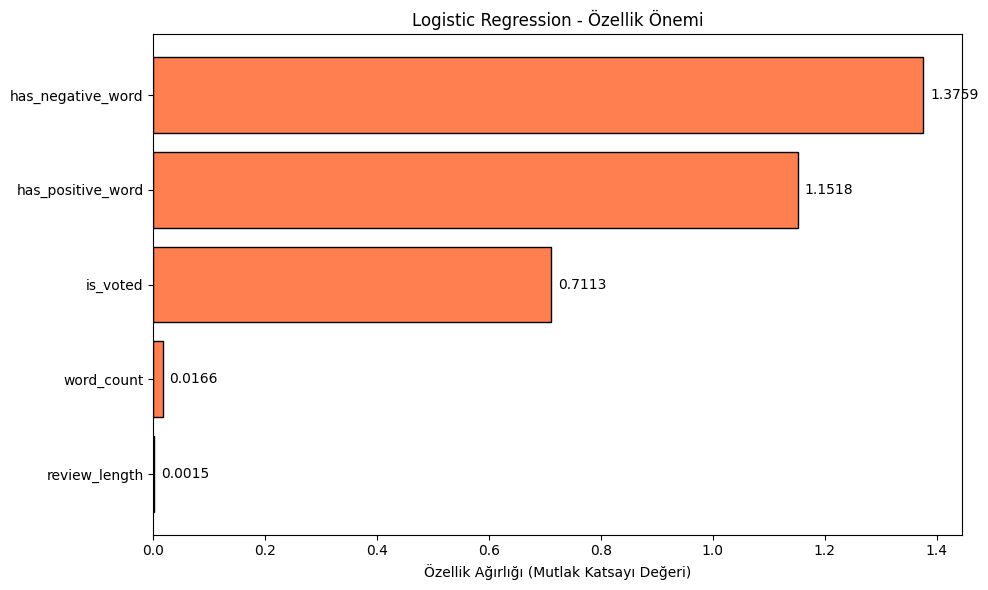

Feature Importance grafiği kaydedildi!


In [0]:
# Logistic Regression modelinin katsayılarını (Coefficients) alalım
importances = [abs(float(c)) for c in lr_model.coefficients.toArray()]
features = ["review_length", "word_count", "is_voted", "has_positive_word", "has_negative_word"]

# Verileri düzgün sıralamak için bir DataFrame oluşturalım
df_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
# Katsayı büyüklüğüne göre sıralayalım
df_imp = df_imp.sort_values(by='Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_imp['Feature'], df_imp['Importance'], color='coral', edgecolor='black')

ax.set_xlabel('Özellik Ağırlığı (Mutlak Katsayı Değeri)')
ax.set_title('Logistic Regression - Özellik Önemi')
ax.bar_label(bars, padding=5, fmt='%.4f')

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/steam/adim7_lr_feature_importance.png", bbox_inches='tight', dpi=300)
plt.show()
print("Feature Importance grafiği kaydedildi!")

Karşılaştırmalı grafik 'adim7_gercek_vs_tahmin_pie.png' adıyla kaydedildi!


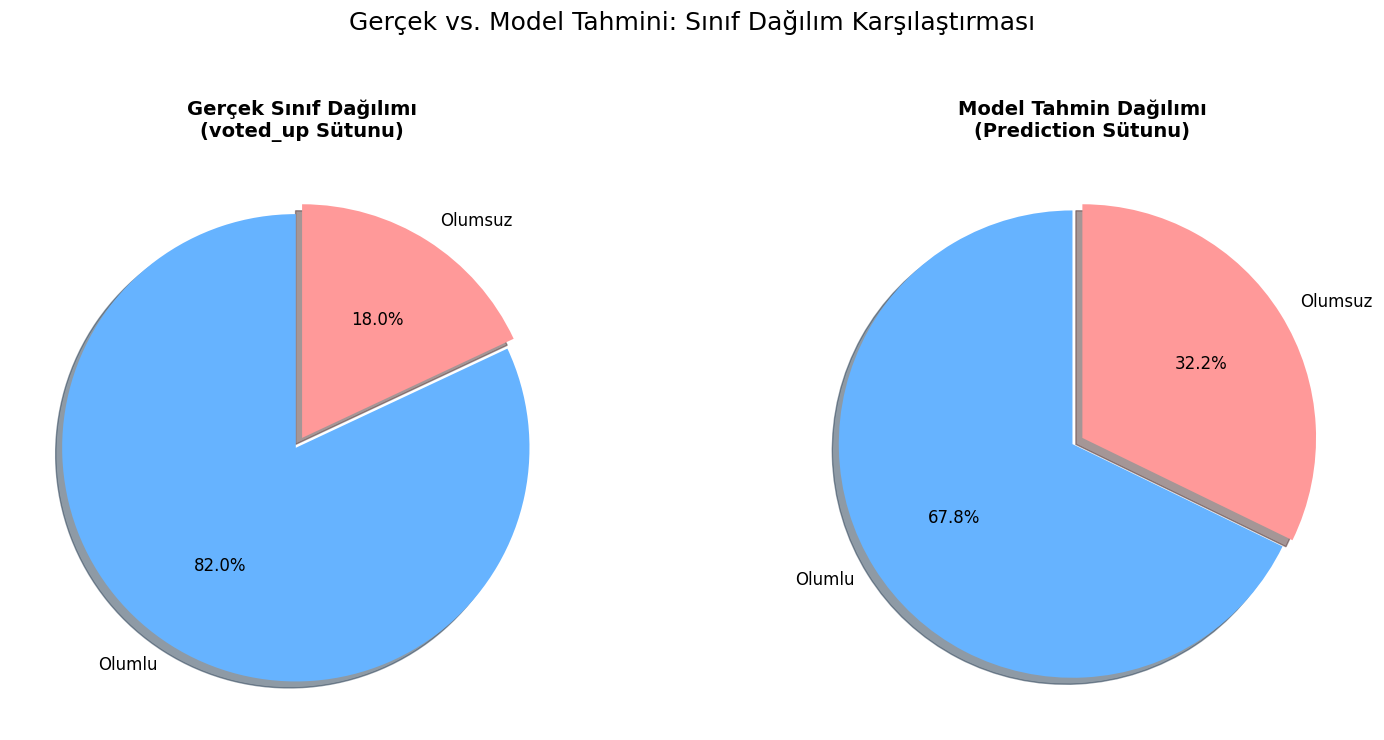

In [0]:
import matplotlib.pyplot as plt
from pyspark.ml.feature import VectorAssembler

# 1. VERİLERİ HAZIRLAMA
# -------------------------------------------------------------------------
# Gerçek verileri okuyalım (Silver)
df_silver = spark.read.format("delta").load("/Volumes/workspace/default/steam/steam_reviews_silver")

# Model tahmini için özellik tablosunu hazırlayalım
df_features = spark.read.format("delta").load("/Volumes/workspace/default/steam/steam_reviews_features")
feature_columns = ["review_length", "word_count", "is_voted", "has_positive_word", "has_negative_word"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_assembled = assembler.transform(df_features)

# Model ile tahmin yapalım (Tüm veri seti üzerinde)
# Not: lr_model değişkeninin önceki hücrelerde tanımlanmış olması gerekir.
full_predictions = lr_model.transform(df_assembled)

# 2. HESAPLAMALAR
# -------------------------------------------------------------------------
# A) Gerçek Dağılım (voted_up sütunu)
real_counts = df_silver.groupBy("voted_up").count().collect()
real_pos = next((row['count'] for row in real_counts if str(row['voted_up']) in ["1", "true"]), 0)
real_neg = next((row['count'] for row in real_counts if str(row['voted_up']) in ["-1", "0", "false"]), 0)

# B) Model Tahmin Dağılımı (prediction sütunu)
pred_counts = full_predictions.groupBy("prediction").count().collect()
pred_pos = next((row['count'] for row in pred_counts if row['prediction'] == 1.0), 0)
pred_neg = next((row['count'] for row in pred_counts if row['prediction'] == 0.0), 0)

# 3. GÖRSELLEŞTİRME (Yan Yana İki Pasta Grafik)
# -------------------------------------------------------------------------
labels = ['Olumlu', 'Olumsuz']
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Sol Grafik: Gerçek Veri
ax1.pie([real_pos, real_neg], explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax1.set_title('Gerçek Sınıf Dağılımı\n(voted_up Sütunu)', fontsize=14, fontweight='bold')

# Sağ Grafik: Model Tahmini
ax2.pie([pred_pos, pred_neg], explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
ax2.set_title('Model Tahmin Dağılımı\n(Prediction Sütunu)', fontsize=14, fontweight='bold')

plt.suptitle('Gerçek vs. Model Tahmini: Sınıf Dağılım Karşılaştırması', fontsize=18, y=1.05)
plt.tight_layout()

# Kaydetme
plt.savefig("/Volumes/workspace/default/steam/adim7_gercek_vs_tahmin_pie.png", bbox_inches='tight', dpi=300)
print("Karşılaştırmalı grafik 'adim7_gercek_vs_tahmin_pie.png' adıyla kaydedildi!")

--- 1. İNTERAKTİF GRAFİK ---



--- 2. HİSTOGRAM KAYDEDİLDİ ---


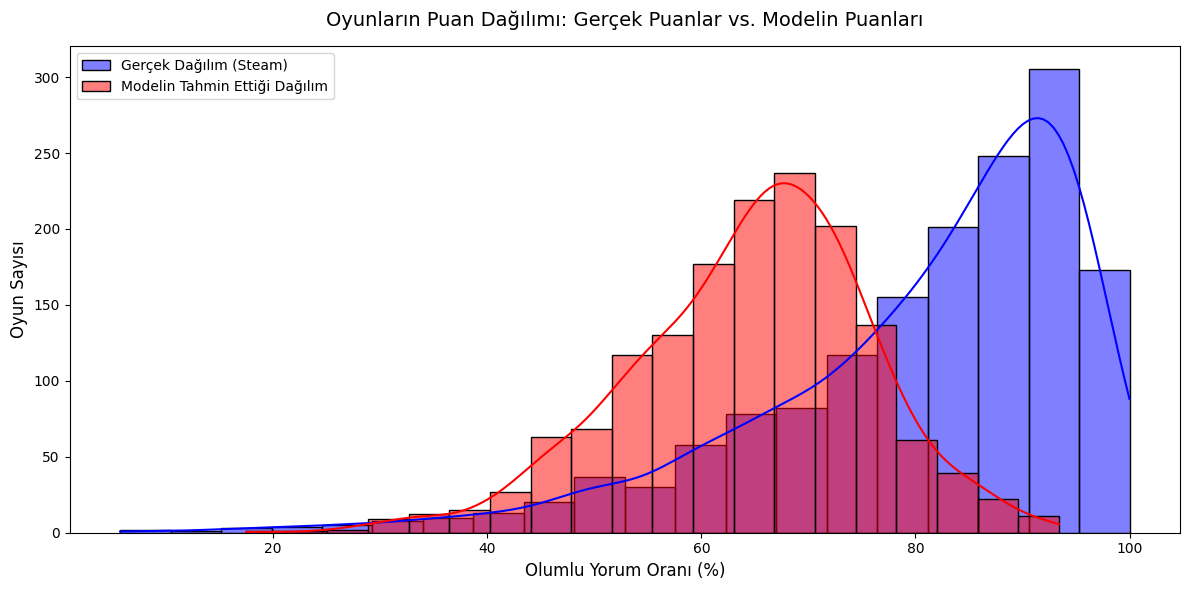


--- 3. STATİK SCATTER KAYDEDİLDİ ---


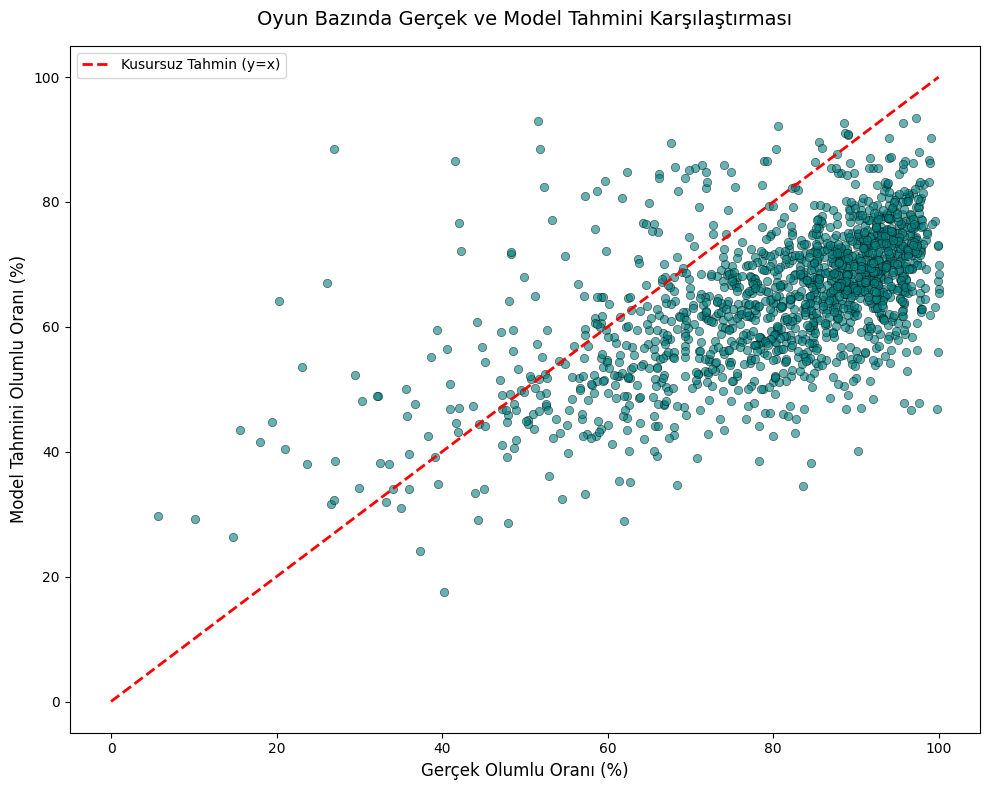

In [0]:
from pyspark.sql.functions import col, avg, count, round, when
from pyspark.ml.feature import VectorAssembler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd

# ==========================================
# 1. VERİ HAZIRLIĞI: Hem Gerçek Hem Tahmin Oranlarını Hesaplama
# ==========================================
# A) Tüm veriyi okuyoruz
features_path = "/Volumes/workspace/default/steam/steam_reviews_features"
df_full_features = spark.read.format("delta").load(features_path)

# B) EKSİK OLAN KISIM: Gerçek değerleri (voted_up) 'label' (1.0 ve 0.0) formatına çeviriyoruz
df_full_features = df_full_features.withColumn(
    "label", 
    when(col("voted_up").cast("string").isin("1", "true"), 1.0).otherwise(0.0)
)

# C) Modelin anlayacağı vektör formatına çeviriyoruz
feature_columns = ["review_length", "word_count", "is_voted", "has_positive_word", "has_negative_word"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_full_assembled = assembler.transform(df_full_features)

# D) Model ile tahmin (Prediction) yapıyoruz
# Not: lr_model'in bellekte yüklü/eğitilmiş olduğunu varsayıyoruz
full_predictions = lr_model.transform(df_full_assembled)

# E) Karşılaştırma Analizi: Gerçek oran vs Tahmini oran
game_analysis_compare = full_predictions.groupBy("app_name").agg(
    count("*").alias("toplam_yorum_sayisi"),
    # Gerçek veri setindeki (label) olumlu yorum oranı
    round(avg("label") * 100, 2).alias("gercek_olumlu_yuzdesi"),
    # Modelimizin (prediction) tahmin ettiği olumlu yorum oranı
    round(avg("prediction") * 100, 2).alias("tahmini_olumlu_yuzdesi")
).filter(col("toplam_yorum_sayisi") >= 500)

# Spark tablosunu çizim için Pandas'a çeviriyoruz
df_oyunlar = game_analysis_compare.toPandas()

# Hata payını (Gerçek - Tahmin) hesaplayıp yeni bir sütun ekleyelim (Renk için kullanacağız)
df_oyunlar['hata_payi'] = abs(df_oyunlar['gercek_olumlu_yuzdesi'] - df_oyunlar['tahmini_olumlu_yuzdesi'])

# ==========================================
# GÖRSEL 1: İNTERAKTİF GERÇEK vs TAHMİN GRAFİĞİ (PLOTLY BUBBLE CHART)
# ==========================================
# ==========================================
# GÖRSEL 1: İNTERAKTİF GERÇEK vs TAHMİN GRAFİĞİ (Daha Belirgin Renkler)
# ==========================================
fig_interactive = px.scatter(
    df_oyunlar, 
    x='gercek_olumlu_yuzdesi', 
    y='tahmini_olumlu_yuzdesi',
    hover_name='app_name',
    size='toplam_yorum_sayisi', 
    color='hata_payi', 
    # DEĞİŞİKLİK 1: Hata azsa Yeşil, ortaysa Sarı, çoksa Kırmızı
    color_continuous_scale='RdYlGn_r', 
    title='Gerçek vs. Tahmini Beğeni Oranı Karşılaştırması',
    labels={
        'gercek_olumlu_yuzdesi': 'Gerçek Olumlu Oranı (%)', 
        'tahmini_olumlu_yuzdesi': 'Model Tahmini Olumlu Oranı (%)',
        'hata_payi': 'Yanılma Payı (%)'
    },
    # DEĞİŞİKLİK 2: Renkler daha canlı ve opak
    opacity=0.9
)

# DEĞİŞİKLİK 3: Baloncukların birbirine karışmaması için ince koyu gri dış çerçeve
fig_interactive.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))

# Kusursuz tahmin çizgisi
fig_interactive.add_shape(type="line", x0=0, y0=0, x1=100, y1=100, line=dict(color="blue", dash="dash"))

print("--- 1. İNTERAKTİF GRAFİK ---")
fig_interactive.show()

# ==========================================
# GÖRSEL 2: ÖRTÜŞEN HİSTOGRAMLAR 
# ==========================================
fig_hist, ax_hist = plt.subplots(figsize=(12, 6))

sns.histplot(data=df_oyunlar, x='gercek_olumlu_yuzdesi', bins=20, kde=True, color='blue', alpha=0.5, label='Gerçek Dağılım (Steam)', ax=ax_hist)
sns.histplot(data=df_oyunlar, x='tahmini_olumlu_yuzdesi', bins=20, kde=True, color='red', alpha=0.5, label='Modelin Tahmin Ettiği Dağılım', ax=ax_hist)

ax_hist.set_title('Oyunların Puan Dağılımı: Gerçek Puanlar vs. Modelin Puanları', fontsize=14, pad=15)
ax_hist.set_xlabel('Olumlu Yorum Oranı (%)', fontsize=12)
ax_hist.set_ylabel('Oyun Sayısı', fontsize=12)
ax_hist.legend()

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/steam/adim7_karsilastirmali_histogram.png", bbox_inches='tight', dpi=300)
print("\n--- 2. HİSTOGRAM KAYDEDİLDİ ---")
plt.show()

# ==========================================
# GÖRSEL 3: STATİK SCATTER 
# ==========================================
fig_scatter, ax_scatter = plt.subplots(figsize=(10, 8)) 

sns.scatterplot(
    data=df_oyunlar, 
    x='gercek_olumlu_yuzdesi', 
    y='tahmini_olumlu_yuzdesi', 
    alpha=0.6,
    color='teal',
    edgecolor='black',
    ax=ax_scatter
)

ax_scatter.plot([0, 100], [0, 100], color='red', linestyle='--', linewidth=2, label='Kusursuz Tahmin (y=x)')

ax_scatter.set_title('Oyun Bazında Gerçek ve Model Tahmini Karşılaştırması', fontsize=14, pad=15)
ax_scatter.set_xlabel('Gerçek Olumlu Oranı (%)', fontsize=12)
ax_scatter.set_ylabel('Model Tahmini Olumlu Oranı (%)', fontsize=12)
ax_scatter.legend()

plt.tight_layout()
plt.savefig("/Volumes/workspace/default/steam/adim7_statik_karsilastirma_scatter.png", bbox_inches='tight', dpi=300)
print("\n--- 3. STATİK SCATTER KAYDEDİLDİ ---")
plt.show()